# SUPERMARKET SALES ANALYSIS


## PROJECT OVERVIEW
 Supermarkets generate large volumes of transaction data every day, but struggle to understand what truly drives customer satisfaction.

 This project aims to analyze supermarket sales data from three branches(Yangon, Naypyitaw and Mandalay) to identify the key factors that influence customer satisfaction ratings.

## BUSINESS UNDERSTANDING
This dataset captures sales transactions from a supermarket chain with three branches located in Yangon, Naypyitaw, and Mandalay. Each row represents a transaction made by a customer.The business accepts three payment methods: cash, e-wallet, and credit card.

## OBJECTIVES
1. To analyze supermarket sales data and identify the factors that influence customer satisfaction ratings and purchasing patterns.
2. To develop and evaluate a Machine Learning model to predict customer satisfaction ratings based on selected sales features.

## VARIABLES

Invoice ID - A unique identifier assigned to each sales transaction.

 Branch - The branch where the transaction occurred. Three branches: A, B, and C.

 City - The city where each branch is located.

 Customer type - Whether the customer is a loyalty Member (with a membership card) or a Normal (walk-in) customer.

 Gender - The gender of the customer — Male or Female.
 
 Product line - The category of products purchased. Six lines: Health & Beauty, Electronic Accessories, Home & Lifestyle, Sports & Travel, Food & Beverages, Fashion Accessories.

 Unit price - The price per single unit of the product purchased, in USD.

 Quantity - Number of items purchased.

 Tax 5% - A 5% tax applied to the cost of goods sold (COGS).

 Total - The total amount paid by the customer, including tax

 Date - The date the transaction took place.

 Time - The time of day the transaction occurred

 Payment - The payment method used: Cash, E-wallet, or Credit card.

 COGS - Cost of goods sold -the direct cost to the supermarket for the goods sold.

 Gross margin % - The gross profit margin percentage. 

 Gross income - The actual profit earned from each transaction.

 Rating - A customer satisfaction rating on a scale of 1 to 10

 * The target variable is Rating, which represents the customer satisfaction score. It measures a customer's overall shopping experience at the supermarket and is what the model aims to predict.


## IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load dataset
df=pd.read_csv("supermarket_sales -.csv")

## DATA UNDERSTANDING

In [3]:
#first 5 rows
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
#check columns
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='str')

In [5]:
# check dupicates
df.duplicated().sum()

np.int64(0)

In [6]:
#values of first row
df.iloc[2]

Invoice ID                        631-41-3108
Branch                                      A
City                                   Yangon
Customer type                          Normal
Gender                                   Male
Product line               Home and lifestyle
Unit price                              46.33
Quantity                                    7
Tax 5%                                16.2155
Total                                340.5255
Date                                 3/3/2019
Time                                    13:23
Payment                           Credit card
cogs                                   324.31
gross margin percentage              4.761905
gross income                          16.2155
Rating                                    7.4
Name: 2, dtype: object

In [7]:
#view last rows
df.tail()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,13:46,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,17:16,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,13:22,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,15:33,Cash,65.82,4.761905,3.2910,4.1
999,849-09-3807,A,Yangon,Member,Female,Fashion accessories,88.34,7,30.9190,649.2990,2/18/2019,13:28,Cash,618.38,4.761905,30.9190,6.6


In [8]:
# check missing values
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [9]:
#total revenue
df["Total"].sum()

np.float64(322966.749)

In [10]:
#best sellng product line
df["Product line"].value_counts()

Product line
Fashion accessories       178
Food and beverages        174
Electronic accessories    170
Sports and travel         166
Home and lifestyle        160
Health and beauty         152
Name: count, dtype: int64

In [11]:
#sales by city
df["City"].value_counts()

City
Yangon       340
Mandalay     332
Naypyitaw    328
Name: count, dtype: int64

In [12]:
#sales by branch
df["Branch"].value_counts()

Branch
A    340
B    332
C    328
Name: count, dtype: int64

In [13]:
df.index

RangeIndex(start=0, stop=1000, step=1)

In [14]:
#summary statistics
df.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [15]:
#number of rows and columns
df.shape

(1000, 17)

In [16]:
df.sort_values(by='Quantity')

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,15:33,Cash,65.82,4.761905,3.2910,4.1
994,652-49-6720,C,Naypyitaw,Member,Female,Electronic accessories,60.95,1,3.0475,63.9975,2/18/2019,11:40,Ewallet,60.95,4.761905,3.0475,5.9
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,13:22,Cash,31.84,4.761905,1.5920,7.7
978,156-20-0370,B,Mandalay,Normal,Female,Electronic accessories,25.45,1,1.2725,26.7225,3/10/2019,18:10,Credit card,25.45,4.761905,1.2725,5.1
35,232-16-2483,C,Naypyitaw,Member,Female,Sports and travel,68.12,1,3.4060,71.5260,1/7/2019,12:28,Ewallet,68.12,4.761905,3.4060,6.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
410,244-08-0162,B,Mandalay,Normal,Female,Health and beauty,34.21,10,17.1050,359.2050,1/2/2019,13:00,Cash,342.10,4.761905,17.1050,5.1
702,191-29-0321,B,Mandalay,Member,Female,Fashion accessories,19.77,10,9.8850,207.5850,2/27/2019,18:57,Credit card,197.70,4.761905,9.8850,5.0
699,751-41-9720,C,Naypyitaw,Normal,Male,Home and lifestyle,97.50,10,48.7500,1023.7500,1/12/2019,16:18,Ewallet,975.00,4.761905,48.7500,8.0
993,690-01-6631,B,Mandalay,Normal,Male,Fashion accessories,17.49,10,8.7450,183.6450,2/22/2019,18:35,Ewallet,174.90,4.761905,8.7450,6.6


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [18]:
# Function to classify rating
def classify_rating(rating):
    if rating <= 5:
        return 'Poor'
    elif rating <= 6:
        return 'Average'
    elif rating <= 8:
        return 'Good'
    else:
        return 'Excellent'

# Apply classification
df['Rating_Category'] = df['Rating'].apply(classify_rating)

# View distribution
print(df['Rating_Category'].value_counts())
print()
print(df[['Rating', 'Rating_Category']].head(10))

Rating_Category
Good         351
Excellent    308
Poor         174
Average      167
Name: count, dtype: int64

   Rating Rating_Category
0     9.1       Excellent
1     9.6       Excellent
2     7.4            Good
3     8.4       Excellent
4     5.3         Average
5     4.1            Poor
6     5.8         Average
7     8.0            Good
8     7.2            Good
9     5.9         Average


## EXPLORATORY DATA ANALYSIS

### RATING DISTRIBUTION

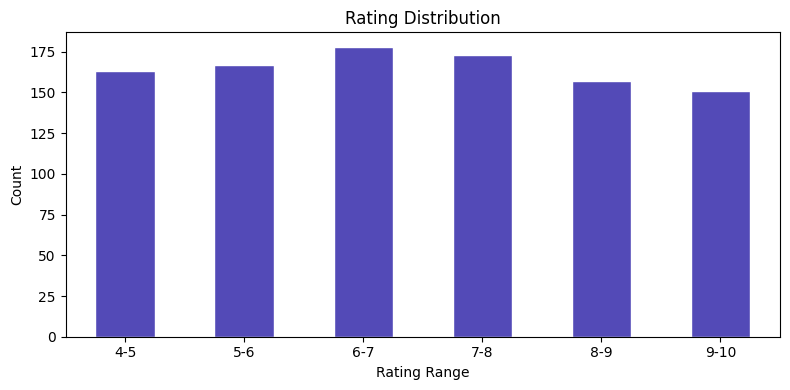

In [19]:
bins = [4, 5, 6, 7, 8, 9, 10]
labels = ['4-5', '5-6', '6-7', '7-8', '8-9', '9-10']

df['Rating_bin'] = pd.cut(df['Rating'], bins=bins, labels=labels)

plt.figure(figsize=(8, 4))
df['Rating_bin'].value_counts().sort_index().plot(kind='bar', color='#534AB7', edgecolor='white')
plt.title('Rating Distribution')
plt.xlabel('Rating Range')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### OBSERVATON
- Ratings are evenly distributed across the ranges.
- The 6–7 range has the highest count, making it the most common rating given by customers.


### GENDER VS RATING

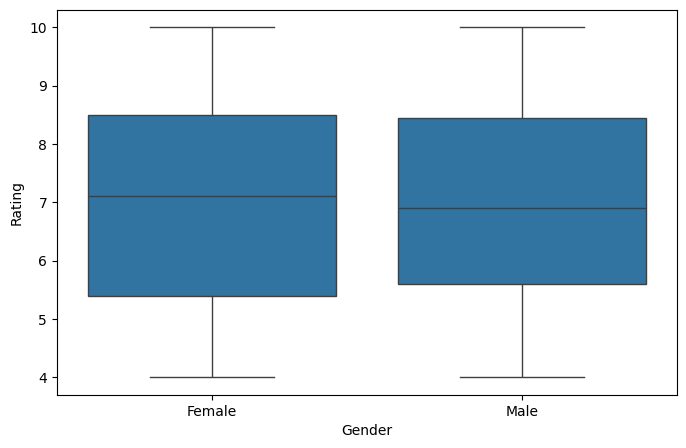

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Gender', y='Rating', data=df)
plt.show()

### OBSERVATION
- The female have slightly higher rating than the male.


### SALES BY PRODUCT LINE

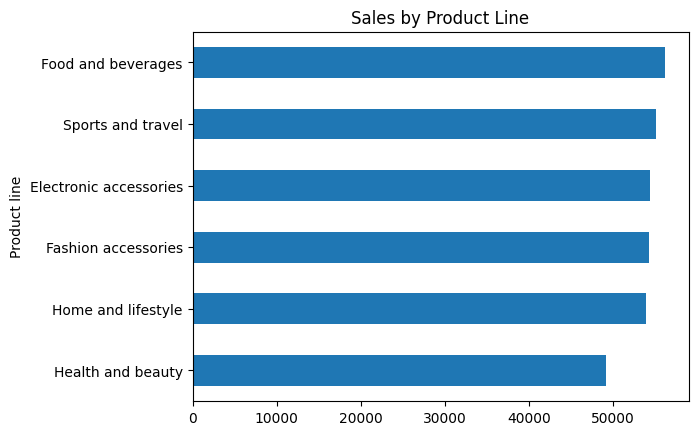

In [21]:
sales = df.groupby('Product line')['Total'].sum().sort_values()
sales.plot(kind='barh')
plt.title('Sales by Product Line')
plt.show()

### OBSERVATION
- Food and beverages generated the highest total sales, making it the top product line
- Health and beauty recorded the lowest total sales, making it the lowest performing product line.

### RATING VS PAYMENT METHOD

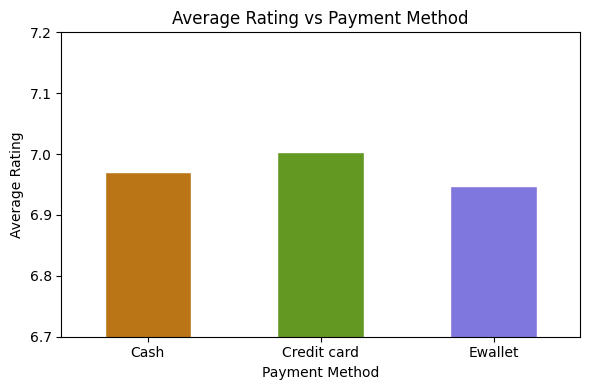

In [22]:
payment_rating = df.groupby('Payment')['Rating'].mean()
plt.figure(figsize=(6, 4))
colors = ['#BA7517', '#639922', '#7F77DD']
payment_rating.plot(kind='bar', color=colors, edgecolor='white')
plt.title('Average Rating vs Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Rating')
plt.ylim(6.7, 7.2)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### OBSERVATION
- Credit card users gave the highest average rating, suggesting that customers who pay by credit card tend to be slightly more satisfied with their shopping experience.


### AVERAGE RATING BY BRANCH

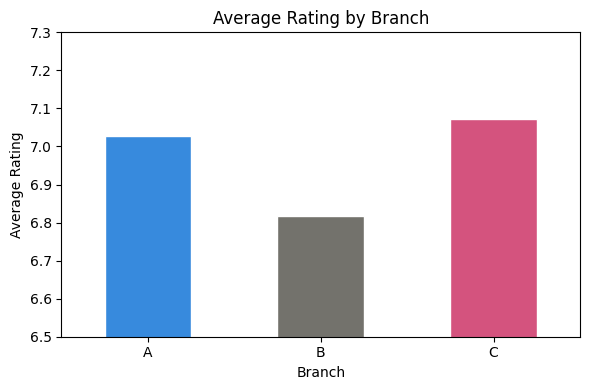

In [23]:
branch_rating = df.groupby('Branch')['Rating'].mean()

plt.figure(figsize=(6, 4))
colors = ['#378ADD', '#73726c', '#D4537E']
branch_rating.plot(kind='bar', color=colors, edgecolor='white')
plt.title('Average Rating by Branch')
plt.xlabel('Branch')
plt.ylabel('Average Rating')
plt.ylim(6.5, 7.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### OBSERVATION
- Branch C recorded the highest average rating , indicating that customers shopping at this branch are the most satisfied overall.

### RATING VS CUSTOMER TYPE

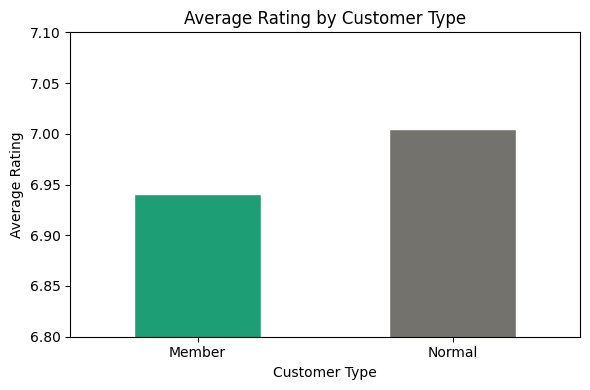

In [24]:
cust_rating = df.groupby('Customer type')['Rating'].mean()

plt.figure(figsize=(6, 4))
colors = ['#1D9E75', '#73726c']
cust_rating.plot(kind='bar', color=colors, edgecolor='white')
plt.title('Average Rating by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Average Rating')
plt.ylim(6.8, 7.1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### OBSERVATION
- Normal customers gave a slightly higher average rating compared to Members, suggesting walk-in customers are more satisfied with their experience.

### CORRELATION HEATMAP

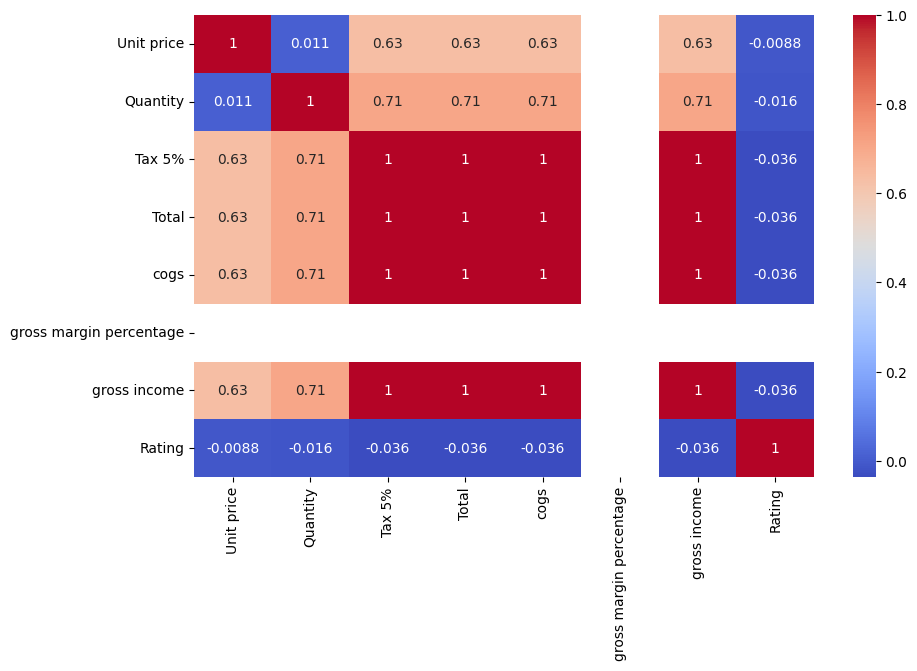

In [25]:


corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

### OBSERVATION

In [26]:
# save cleaned dataset
df.to_csv("cleaned_supermaket_sales.csv")

## FINAL INSIGHTS
- Ratings are evenly distributed across all ranges
- Health & Beauty has the lowest total sales
- Members are less satisfied than normal customers
- Credit card users gave the highest rating 


## RECOMMENDATIONS
- Improve Health & Beauty product line — lowest sales
- Strengthen the membership program — members rate lower than normal customers
- Maintain focus on Food & Beverages — highest sales and rating


## FEATURE ENGINEERING

In [27]:

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Extract useful features
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Hour'] = pd.to_datetime(df['Time']).dt.hour

df[['Date', 'Day', 'Month', 'DayOfWeek', 'Hour',]].head()

C:\Users\chero\AppData\Local\Temp\ipykernel_15888\1352929516.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Time']).dt.hour


,Date,Day,Month,DayOfWeek,Hour
0,2019-01-05,5,1,Saturday,13
1,2019-03-08,8,3,Friday,10
2,2019-03-03,3,3,Sunday,13
3,2019-01-27,27,1,Sunday,20
4,2019-02-08,8,2,Friday,10


In [28]:
# Create Revenue per unit feature
df['Revenue_per_unit'] = df['Total'] / df['Quantity']

In [29]:

# Categorize customer satisfaction

# Classify rating into categories
def classify_rating(rating):
    if rating <= 5:
        return 'Poor'
    elif rating <= 6:
        return 'Average'
    elif rating <= 8:
        return 'Good'
    else:
        return 'Excellent'

df['Rating_Category'] = df['Rating'].apply(classify_rating)
df[['Rating', 'Rating_Category']].head()

,Rating,Rating_Category
0,9.1,Excellent
1,9.6,Excellent
2,7.4,Good
3,8.4,Excellent
4,5.3,Average


In [30]:
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
le = LabelEncoder()

# List of categorical columns to encode
cat_cols = ['Branch', 'Customer type', 'Gender', 'Product line', 'Payment']

# Loop through each categorical column and encode it
for col in cat_cols:
    df[col] = le.fit_transform(df[col])  # Convert text labels to numbers

# Preview the encoded dataframe
print(df.head())

    Invoice ID  Branch       City  Customer type  Gender  Product line  \
0  750-67-8428       0     Yangon              0       0             3   
1  226-31-3081       2  Naypyitaw              1       0             0   
2  631-41-3108       0     Yangon              1       1             4   
3  123-19-1176       0     Yangon              0       1             3   
4  373-73-7910       0     Yangon              1       1             5   

   Unit price  Quantity   Tax 5%     Total  ... gross margin percentage  \
0       74.69         7  26.1415  548.9715  ...                4.761905   
1       15.28         5   3.8200   80.2200  ...                4.761905   
2       46.33         7  16.2155  340.5255  ...                4.761905   
3       58.22         8  23.2880  489.0480  ...                4.761905   
4       86.31         7  30.2085  634.3785  ...                4.761905   

  gross income  Rating  Rating_Category  Rating_bin  Month  Day DayOfWeek  \
0      26.1415     9.1     

In [31]:

#Drop Invoice ID, Date, Time AND City (City = same as Branch)
df = df.drop(['Date', 'Time', 'City'], axis=1)

df.head()

,Invoice ID,Branch,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Payment,...,gross margin percentage,gross income,Rating,Rating_Category,Rating_bin,Month,Day,DayOfWeek,Hour,Revenue_per_unit
0,750-67-8428,0,0,0,3,74.69,7,26.1415,548.9715,2,...,4.761905,26.1415,9.1,Excellent,9-10,1,5,Saturday,13,78.4245
1,226-31-3081,2,1,0,0,15.28,5,3.8200,80.2200,0,...,4.761905,3.8200,9.6,Excellent,9-10,3,8,Friday,10,16.0440
2,631-41-3108,0,1,1,4,46.33,7,16.2155,340.5255,1,...,4.761905,16.2155,7.4,Good,7-8,3,3,Sunday,13,48.6465
3,123-19-1176,0,0,1,3,58.22,8,23.2880,489.0480,2,...,4.761905,23.2880,8.4,Excellent,8-9,1,27,Sunday,20,61.1310
4,373-73-7910,0,1,1,5,86.31,7,30.2085,634.3785,2,...,4.761905,30.2085,5.3,Average,5-6,2,8,Friday,10,90.6255


In [32]:
#Drop Rating_Category from X (it's an object column)
X = df.drop(['Rating', 'Rating_Category','Rating_bin'], axis=1)
y = df['Rating']

In [33]:
#seperate features and target
X = df.drop(
    ['Rating'],
    axis=1
)

y = df['Rating']

print(X.shape)
print(y.shape)

(1000, 20)
(1000,)


In [34]:
# Drop all rating-derived columns from X
X = df.drop(['Rating', 'Rating_Category', 'Rating_bin'], axis=1)

X = df.drop(['Rating', 'Rating_Category', 'Rating_bin', 
             'Tax 5%', 'cogs', 'gross income', 'gross margin percentage'], 
            axis=1)
y = df['Rating']
y = df['Rating']

# Drop any remaining object/text columns
X = X.select_dtypes(exclude='object')

# Fill any remaining NaN with column mean
X = X.fillna(X.mean())

# Confirm everything is clean
print('Shape    :', X.shape)
print('NaN count:', X.isnull().sum().sum())
print('Dtypes   :')
print(X.dtypes)

Shape    : (1000, 12)
NaN count: 0
Dtypes   :
Branch                int64
Customer type         int64
Gender                int64
Product line          int64
Unit price          float64
Quantity              int64
Total               float64
Payment               int64
Month                 int32
Day                   int32
Hour                  int32
Revenue_per_unit    float64
dtype: object


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(800, 12)
(200, 12)


## MACHINE LEARNING

### BASELINE MODEL

In [36]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Baseline predicts mean rating for every transaction
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

baseline_mae  = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2   = r2_score(y_test, baseline_pred)

# Display results as dataframe
baseline_results = pd.DataFrame({
    'Metric' : ['MAE', 'RMSE', 'R²'],
    'Score'  : [baseline_mae, baseline_rmse, baseline_r2]
})

baseline_results




,Metric,Score
0,MAE,1.516801
1,RMSE,1.754562
2,R²,-0.003483


### MODEL 1: LINEAR REGRESSION

In [37]:
from sklearn.linear_model import LinearRegression

# Train Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

lr_mae  = mean_absolute_error(y_test, pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, pred_lr))
lr_r2   = r2_score(y_test, pred_lr)

# Display results as dataframe
lr_results = pd.DataFrame({
    'Metric'   : ['MAE', 'RMSE', 'R²'],
    'Score'    : [lr_mae, lr_rmse, lr_r2],
    'Baseline' : [baseline_mae, baseline_rmse, baseline_r2]
})

lr_results




,Metric,Score,Baseline
0,MAE,1.532662,1.516801
1,RMSE,1.770753,1.754562
2,R²,-0.022089,-0.003483


### MODEL 2:RANDOM FOREST

In [38]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest model
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)

# Predict on test data
pred_rf = rf.predict(X_test)

# Evaluate performance
rf_mae  = mean_absolute_error(y_test, pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, pred_rf))  
rf_r2   = r2_score(y_test, pred_rf)

# Display results as dataframe
rf_results = pd.DataFrame({
    'Metric'   : ['MAE', 'RMSE', 'R²'],
    'Score'    : [rf_mae, rf_rmse, rf_r2],
    'Baseline' : [baseline_mae, baseline_rmse, baseline_r2]
})

rf_results




,Metric,Score,Baseline
0,MAE,1.568580,1.516801
1,RMSE,1.844110,1.754562
2,R²,-0.108528,-0.003483


## CONCLUSION
Linear Regression is selected as the best model as it produced results closest to the baseline with an RMSE of 1.7708 and MAE of 1.5327. The negative R² score confirms that customer satisfaction is largely influenced by intangible factors not captured in the transaction data such as staff behavior, store cleanliness and personal preferences.

In [39]:
import joblib

# Save the trained Linear Regression model
joblib.dump(lr, 'rating_prediction_model.pkl')

['rating_prediction_model.pkl']